# 04 — Modeling & Evaluation

## Notebook Purpose

This notebook builds and evaluates machine learning models to predict daily traffic-related 911 call volume using weather and temporal features.

### Modeling Approach
Models tested:
- Baseline Linear Regression
- Weather-Enhanced Linear Regression
- Random Forest Regressor
- Random Forest with Temporal Lag Features

### Core Research Question
How much predictive value do weather variables add beyond normal temporal traffic patterns?


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

In [3]:
model_data = pd.read_csv("../data/processed/traffic_weather_features.csv")
model_data.head()

,date,traffic_calls,time,temperature_2m_mean (°F),temperature_2m_min (°F),temperature_2m_max (°F),precipitation_sum (inch),rain_sum (inch),snowfall_sum (inch),precipitation_hours (h),...,precip_bucket,temp_bucket,freezing_day,hot_day,heavy_rain_day,traffic_calls_lag_1,precipitation_lag_1,temperature_max_lag_1,traffic_calls_7_day_avg,precipitation_3_day_total
0,2024-01-01,119,1/1/24,38.4,34.9,42.9,0.000,0.000,0.000,0,...,No Rain,Cold,False,False,False,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,138,1/2/24,42.8,38.1,45.9,0.154,0.154,0.000,9,...,Moderate Rain,Cold,False,False,False,119.0,0.000,42.9,NaN,NaN
2,2024-01-03,134,1/3/24,44.8,40.1,47.0,0.150,0.150,0.000,8,...,Moderate Rain,Cold,False,False,False,138.0,0.154,45.9,NaN,0.304
3,2024-01-04,140,1/4/24,44.9,40.2,48.6,0.193,0.193,0.000,14,...,Moderate Rain,Cold,False,False,False,134.0,0.150,47.0,NaN,0.497
4,2024-01-05,178,1/5/24,44.0,40.9,47.3,0.457,0.453,0.028,12,...,Moderate Rain,Cold,False,False,False,140.0,0.193,48.6,NaN,0.800


In [4]:
model_data["date"] = pd.to_datetime(model_data["date"])

In [5]:
model_data = model_data.dropna()

In [6]:
baseline_features = [
    "day_of_week_num",
    "month",
    "weekend"
]

weather_features = [
    "precipitation_sum (inch)",
    "temperature_2m_max (°F)",
    "temperature_2m_min (°F)",
    "rain_day",
    "heavy_rain_day",
    "hot_day",
    "freezing_day"
]

all_features = baseline_features + weather_features

In [7]:
all_features = baseline_features + weather_features

In [8]:
y = model_data["traffic_calls"]

In [9]:
X_baseline = model_data[baseline_features]

In [10]:
X_weather = model_data[all_features]

In [11]:
bool_cols = [
    "weekend",
    "rain_day",
    "heavy_rain_day",
    "hot_day",
    "freezing_day"
]

model_data[bool_cols] = model_data[bool_cols].astype(int)

In [12]:
Xb_train, Xb_test, y_train, y_test = train_test_split(
    X_baseline,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
Xw_train, Xw_test, _, _ = train_test_split(
    X_weather,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
baseline_model = LinearRegression()

baseline_model.fit(Xb_train, y_train)

baseline_preds = baseline_model.predict(Xb_test)

In [15]:
print("BASELINE MODEL")

print(
    "MAE:",
    mean_absolute_error(y_test, baseline_preds)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, baseline_preds))
)

print(
    "R2:",
    r2_score(y_test, baseline_preds)
)

BASELINE MODEL
MAE: 30.410603153220954
RMSE: 38.51604285785875
R2: 0.0853155766170135


In [16]:
weather_model = LinearRegression()

weather_model.fit(Xw_train, y_train)

weather_preds = weather_model.predict(Xw_test)

In [17]:
print("WEATHER MODEL")

print(
    "MAE:",
    mean_absolute_error(y_test, weather_preds)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, weather_preds))
)

print(
    "R2:",
    r2_score(y_test, weather_preds)
)

WEATHER MODEL
MAE: 30.030501138065755
RMSE: 37.96346639950842
R2: 0.11137263774892281


In [18]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(Xw_train, y_train)

rf_preds = rf.predict(Xw_test)

In [19]:
print("RANDOM FOREST")

print(
    "MAE:",
    mean_absolute_error(y_test, rf_preds)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, rf_preds))
)

print(
    "R2:",
    r2_score(y_test, rf_preds)
)

RANDOM FOREST
MAE: 29.165029069767442
RMSE: 37.402659111025535
R2: 0.13743284104152964


In [20]:
importance = pd.DataFrame({
    "feature": X_weather.columns,
    "importance": rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
5,temperature_2m_min (°F),0.265659
4,temperature_2m_max (°F),0.253450
0,day_of_week_num,0.205328
3,precipitation_sum (inch),0.123036
1,month,0.120257
6,rain_day,0.012766
2,weekend,0.011833
7,heavy_rain_day,0.003826
9,freezing_day,0.002237
8,hot_day,0.001607


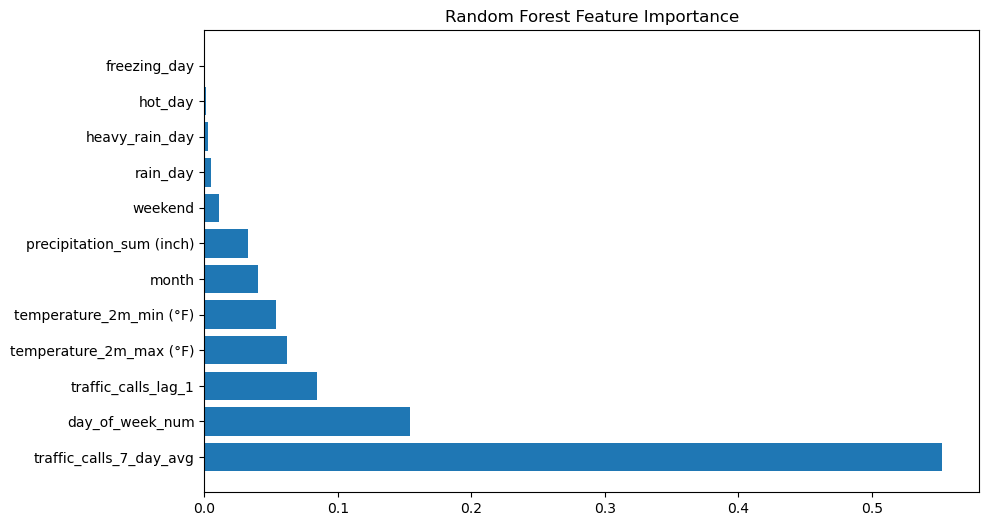

<Figure size 640x480 with 0 Axes>

In [30]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.title("Random Forest Feature Importance")

plt.show()
plt.savefig("../outputs/rf_feature_importance.png")

Built a machine learning model using public 911 dispatch and weather data to evaluate whether weather conditions improved prediction of traffic-related emergency call volume. Temporal patterns such as weekday and seasonality explained a meaningful portion of variability, while weather variables — particularly temperature — added measurable predictive value. Random Forest models outperformed linear regression, suggesting nonlinear operational relationships between environmental conditions and emergency demand.

In [22]:
weather_features = [
    "precipitation_sum (inch)",
    "temperature_2m_max (°F)",
    "temperature_2m_min (°F)",
    "rain_day",
    "heavy_rain_day",
    "hot_day",
    "freezing_day",
    "traffic_calls_lag_1",
    "traffic_calls_7_day_avg"
]

In [23]:
all_features = baseline_features + weather_features

In [24]:
# Rebuild X and y
X_weather = model_data[all_features]
y = model_data["traffic_calls"]

# Split again
Xw_train, Xw_test, y_train, y_test = train_test_split(
    X_weather,
    y,
    test_size=0.2,
    random_state=42
)

# Retrain random forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(Xw_train, y_train)

# Predict
rf_preds = rf.predict(Xw_test)

# Metrics
print("RANDOM FOREST WITH LAG FEATURES")
print("MAE:", mean_absolute_error(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("R2:", r2_score(y_test, rf_preds))

RANDOM FOREST WITH LAG FEATURES
MAE: 21.081133720930232
RMSE: 27.501553484134266
R2: 0.5336602732312984


In [25]:
importance = pd.DataFrame({
    "feature": Xw_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importance

,feature,importance
11,traffic_calls_7_day_avg,0.552744
0,day_of_week_num,0.154173
10,traffic_calls_lag_1,0.084246
4,temperature_2m_max (°F),0.062341
5,temperature_2m_min (°F),0.053983
1,month,0.039913
3,precipitation_sum (inch),0.032700
2,weekend,0.010748
6,rain_day,0.004753
7,heavy_rain_day,0.002627


| Model             |   MAE |  RMSE |    R² |
| ----------------- | ----: | ----: | ----: |
| Baseline Linear   | 30.41 | 38.52 | 0.085 |
| Weather Linear    | 30.03 | 37.96 | 0.111 |
| RF Weather        | 29.17 | 37.40 | 0.137 |
| RF + Lag Features | 21.08 | 27.50 | 0.534 |


In [31]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear",
        "Weather Linear",
        "RF Weather",
        "RF + Lag Features"
    ],
    "MAE": [
        30.41,
        30.03,
        29.17,
        21.08
    ],
    "RMSE": [
        38.52,
        37.96,
        37.40,
        27.50
    ],
    "R2": [
        0.085,
        0.111,
        0.137,
        0.534
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Baseline Linear,30.41,38.52,0.085
1,Weather Linear,30.03,37.96,0.111
2,RF Weather,29.17,37.40,0.137
3,RF + Lag Features,21.08,27.50,0.534


In [32]:
comparison.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

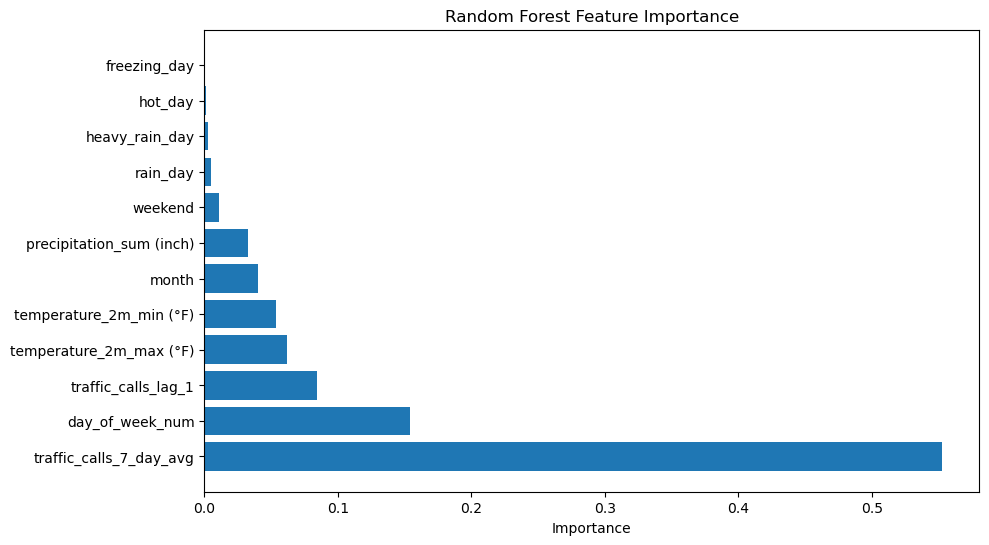

<Figure size 640x480 with 0 Axes>

In [28]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.show()

plt.savefig("../outputs/rf_lag_feature_importance.png")

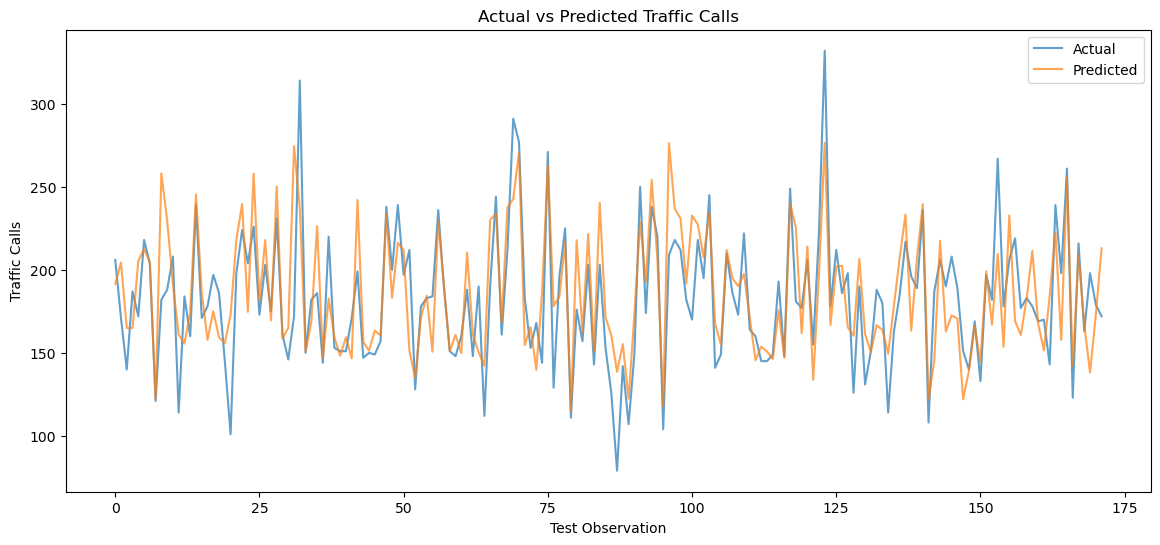

In [29]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label="Actual",
    alpha=0.7
)

plt.plot(
    rf_preds,
    label="Predicted",
    alpha=0.7
)

plt.legend()

plt.title("Actual vs Predicted Traffic Calls")

plt.xlabel("Test Observation")
plt.ylabel("Traffic Calls")

plt.savefig("../outputs/actual_vs_predicted_traffic_calls.png")

plt.show()

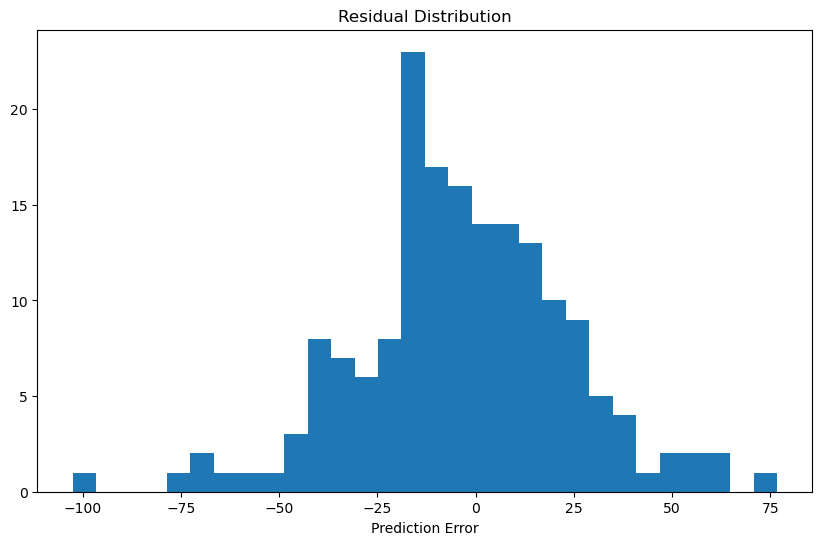

In [42]:
residuals = y_test - rf_preds
plt.figure(figsize=(10,6))

plt.hist(residuals, bins=30)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()

## Key Findings

- Weather variables improved predictive performance modestly beyond temporal features alone.
- Random Forest models substantially outperformed linear regression models.
- Lagged traffic-call features were among the strongest predictors, indicating strong temporal autocorrelation in traffic-related emergency demand.
- Temperature variables contributed more predictive value than binary weather-condition flags.
- Several anomalous traffic-call spikes in June 2025 were driven primarily by moving-violation events rather than collision-related incidents.

## Model Evaluation Metrics

### MAE — Mean Absolute Error
Measures the average prediction error in units of traffic calls.

### RMSE — Root Mean Squared Error
Penalizes large prediction errors more heavily than MAE.

### R² — Coefficient of Determination
Measures how much variability in traffic call volume is explained by the model.


## Modeling Conclusions

Key findings from the modeling process:

- Weather variables improved prediction performance modestly beyond baseline temporal features.
- Random Forest models outperformed linear regression models, suggesting nonlinear operational relationships.
- Lagged traffic features dramatically improved predictive accuracy, indicating strong temporal autocorrelation in emergency traffic demand.
- Temperature variables contributed more predictive signal than binary weather flags.
- Several traffic-call spikes in June 2025 were driven primarily by moving-violation events rather than collision-related incidents.
